# Color-based Nearest Neighbors Image Retrieval (Pattern Matching)

Metode: Dominant Intensity

Sample case: Deteksi nominal uang kertas

# 0. Data path

In [ ]:
path_referensi = "/dataset_uang/"
path_uji = "/uang_no_edit/"

# 1. Load Citra Referensi

In [4]:
import os

file_referensi = os.listdir(path_referensi)
file_referensi_sorted = sorted(file_referensi)
print(file_referensi_sorted)

['01_100_(1)belakang.jpg', '02_100_(1)depan.jpg', '03_100_(2)belakang.jpg', '04_100_(2)depan.jpg', '05_100_(3)belakang.jpg', '06_100_(3)depan.jpg', '11_50_(3)depan.jpg', '12_50_(3)belakang.jpg', '13_50_(2)depan_50.jpg', '14_50_(2)belakang.jpg', '15_50_(1)depan.jpg', '16_50_(1)belakang.jpg', '21_20_(3)depan.jpg', '22_20_(3)belakang.jpg', '23_20_(2)depan.jpg', '24_20_(2)belakang.jpg', '25_20_(1)depan.jpg', '26_20_(1)belakang.jpg', '31_10_(3)depan.jpg', '32_10_(3)belakang.jpg', '33_10_(2)depan.jpg', '34_10_(2)belakang.jpg', '35_10_(1)depan.jpg', '36_10_(1)belakang.jpg', '41_5_(3)depan.jpg', '42_5_(3)belakang.jpg', '43_5_(2)depan.jpg', '44_5_(2)belakang.jpg', '45_5_(1)depan.jpg', '46_5_(1)belakang.jpg', '51_2_(3)depan.jpg', '52_2_(3)belakang.jpg', '53_2_(2)depan.jpg', '54_2_(2)belakang.jpg', '55_2_(1)depan.jpg', '56_2_(1)belakang.jpg', '61_1_(3)depan.jpg', '62_1_(3)belakang.jpg', '63_1_(2)depan.jpg', '64_1_(2)belakang.jpg', '65_1_(1)depan.jpg', '66_1_(1)belakang.jpg']


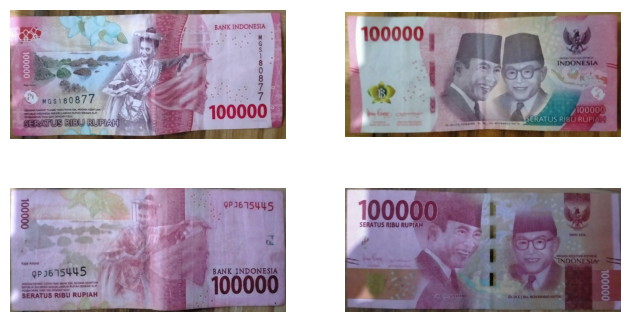

In [5]:
from matplotlib import pyplot as plt

# Sample file referensi
for i in range(4):
  plt.subplot(2, 2, i+1)
  plt.imshow(plt.imread(path_referensi + file_referensi_sorted[i]))
  plt.tight_layout()
  plt.axis('off')

# 2. Ekstraksi fitur untuk citra referensi

In [6]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def create_features(img):
  R = np.mean(img[:,:,0].flatten())
  G = np.mean(img[:,:,1].flatten())
  B = np.mean(img[:,:,2].flatten())
  img_hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
  H = np.mean(img_hsv[0])
  return [R,G,B,H]

In [7]:
feat_referensi = []
for file_img in file_referensi_sorted:
  img = plt.imread(path_referensi + file_img)
  feat_referensi.append(create_features(img))

print(feat_referensi)

[[158.17037600694698, 142.14191902251184, 162.26095786081487, 72.82104355325572], [141.37545300524405, 131.1855114158935, 136.33275272287213, 96.10216216216216], [154.9350965577733, 134.53549429455452, 162.49422371342143, 80.43917106115275], [118.92904713455077, 99.06217418211187, 119.51747030708609, 53.57697343808455], [148.73289865359115, 134.19742359499367, 138.30290223920412, 92.86391976145296], [137.32779715704947, 126.94761209123524, 132.88167711261963, 91.52371899330075], [104.09043010025505, 104.57384046093925, 99.43863547375811, 52.33699250740547], [101.20064830868542, 107.28848313093393, 107.9443147561779, 49.79773206751055], [104.09039802769733, 104.57393435661723, 99.43854288420239, 52.33551141313818], [101.20064830868542, 107.28848313093393, 107.9443147561779, 49.79773206751055], [104.09047175104264, 104.57382681921787, 99.43854114270604, 52.34657605854679], [101.2011356345399, 107.28846583576384, 107.94439985453691, 49.81258790436006], [148.32595353744037, 167.74729759628

# 3. Load citra yang akan dideteksi

In [8]:
file_uji = os.listdir(path_uji)
print(file_uji)

['01_100_(1)belakang.jpg', '02_100_(1)depan.jpg', '03_100_(2)belakang.jpg', '04_100_(2)depan.jpg']


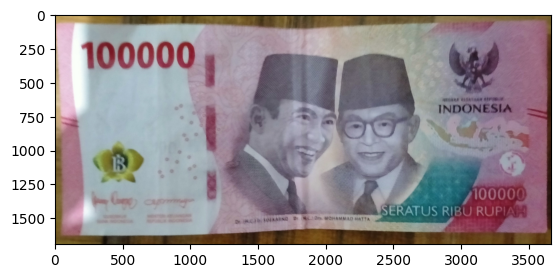

In [9]:
ID_UJI = 1

img_uji = plt.imread(path_uji + file_uji[ID_UJI])

plt.imshow(img_uji)

# 4. Ekstraksi fitur gambar yang diuji

In [10]:
feat_uji = create_features(img_uji)
print(feat_uji)

[141.43687981985855, 131.22482879397774, 136.33740268314736, 96.23705523705523]


# 5. Hitung jarak dari fitur gambar ke referensi

In [11]:
import pandas as pd

hasil = []
for idx,referensi in enumerate(feat_referensi):
  jarak = np.linalg.norm(np.array(feat_uji) - np.array(referensi))
  temp = {
      "nominal_ditanyakan": int(file_uji[ID_UJI].split("_")[1])*1000,
      "nominal_referensi": int(file_referensi[idx].split("_")[1])*1000,
      "jarak":jarak,
  }
  hasil.append(temp)

df_jarak = pd.DataFrame(hasil)
df_jarak.head()

,nominal_ditanyakan,nominal_referensi,jarak
0,100000,100000,40.243423
1,100000,100000,0.153417
2,100000,100000,33.569552
3,100000,100000,60.364158
4,100000,100000,8.792579


# 6. Ambil k terdekat

In [12]:
# sort by jarak dan ambil k terdekat
K_NEAREST = 4

df_k = df_jarak.sort_values(by=['jarak']).head(K_NEAREST)
df_k

,nominal_ditanyakan,nominal_referensi,jarak
1,100000,100000,0.153417
5,100000,100000,8.326867
4,100000,100000,8.792579
29,100000,5000,18.294515


In [13]:
# ambil nilai prediksi dari 5 nilai tadi
df_freq = df_k['nominal_referensi'].value_counts()
df_freq

,count
nominal_referensi,
100000,3
5000,1


In [14]:
print("Prediksi nilai nominal mata uang berdasarkan data referensi adalah: ")
print(df_freq.index[0])

Prediksi nilai nominal mata uang berdasarkan data referensi adalah: 
100000
